# Part A — Transfer Learning Experiments
Comparing base models vs transfer learning options on CIFAR-10.

In [1]:
import sys
sys.path.append('.')

import copy
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    jaccard_score, confusion_matrix, classification_report
)

from models.ResNet import ResNet, BasicBlock
from models.VGG import VGG
from models.Transfer import Transfer_Config, build_transfer_model
from train import get_loaders, train_one_epoch, validate

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CLASSES = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']
print(f'Using device: {DEVICE}')

Using device: cuda


In [2]:
# ── Shared params dict used by get_loaders / get_transforms ──────────────────
BASE_PARAMS = {
    'dataset': 'cifar10', 'data_dir': './data', 'num_workers': 2,
    'mean': (0.4914, 0.4822, 0.4465), 'std': (0.2023, 0.1994, 0.2010),
    'batch_size': 64, 'learning_rate': 1e-3, 'weight_decay': 1e-4,
    'epochs': 20, 'log_interval': 100, 'resize_224': False,
}

train_loader, val_loader = get_loaders(BASE_PARAMS)
print(f'Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}')

Train batches: 782  |  Val batches: 157


In [3]:
# ── Training helper ───────────────────────────────────────────────────────────
def train_model(model, params, train_loader, val_loader, save_path):
    """Train model and return history of train/val loss and accuracy."""
    criterion = nn.CrossEntropyLoss()
    trainable = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.Adam(trainable, lr=params['learning_rate'],
                                 weight_decay=params['weight_decay'])
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_acc, best_weights = 0.0, None

    for epoch in range(1, params['epochs'] + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer,
                                          criterion, DEVICE, params['log_interval'])
        val_loss, val_acc = validate(model, val_loader, criterion, DEVICE)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f'Epoch {epoch}/{params["epochs"]}  '
              f'train_loss={tr_loss:.4f} train_acc={tr_acc:.4f}  '
              f'val_loss={val_loss:.4f} val_acc={val_acc:.4f}')

        if val_acc > best_acc:
            best_acc = val_acc
            best_weights = copy.deepcopy(model.state_dict())
            torch.save(best_weights, save_path)

    model.load_state_dict(best_weights)
    print(f'Best val acc: {best_acc:.4f}')
    return history

In [4]:
# ── Evaluation helper (all metrics) ──────────────────────────────────────────
def evaluate(model, loader):
    """Return dict with loss, accuracy, per-class metrics, IoU, F1, confusion matrix."""
    model.eval()
    criterion = nn.CrossEntropyLoss()
    all_preds, all_labels = [], []
    total_loss, n = 0.0, 0

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            out = model(imgs)
            total_loss += criterion(out, labels).item() * imgs.size(0)
            preds = out.argmax(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            n += imgs.size(0)

    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)

    cm = confusion_matrix(y_true, y_pred)
    per_class_acc = cm.diagonal() / cm.sum(axis=1)

    return {
        'loss':          total_loss / n,
        'accuracy':      (y_true == y_pred).mean(),
        'per_class_acc': per_class_acc,
        'f1_macro':      f1_score(y_true, y_pred, average='macro'),
        'f1_per_class':  f1_score(y_true, y_pred, average=None),
        'precision':     precision_score(y_true, y_pred, average=None),
        'recall':        recall_score(y_true, y_pred, average=None),
        'iou_per_class': jaccard_score(y_true, y_pred, average=None),
        'mean_iou':      jaccard_score(y_true, y_pred, average='macro'),
        'confusion_matrix': cm,
    }

## Experiment 1 — Base ResNet-18 (from scratch)

In [ ]:
resnet_base = ResNet(BasicBlock, [2, 2, 2, 2], num_classes=10).to(DEVICE)
params_base = {**BASE_PARAMS, 'epochs': 30}
hist_resnet = train_model(resnet_base, params_base, train_loader, val_loader,
                          save_path='best_resnet_base.pth')
metrics_resnet = evaluate(resnet_base, val_loader)

  [100/782] loss: 1.9586  acc: 0.2811
  [200/782] loss: 1.8189  acc: 0.3263
  [300/782] loss: 1.7322  acc: 0.3584


## Experiment 2 — Base VGG-16 (from scratch)

In [ ]:
vgg_base = VGG(depth='16', num_class=10).to(DEVICE)
params_vgg = {**BASE_PARAMS, 'epochs': 20}
hist_vgg = train_model(vgg_base, params_vgg, train_loader, val_loader,
                       save_path='best_vgg_base.pth')
metrics_vgg = evaluate(vgg_base, val_loader)

  [100/782] loss: 2.3733  acc: 0.1197
  [200/782] loss: 2.2564  acc: 0.1433
  [300/782] loss: 2.1714  acc: 0.1567
  [400/782] loss: 2.1217  acc: 0.1651


## Experiment 3 — Transfer ResNet-18 Option 1 (resize 224, freeze backbone)

In [7]:
params_opt1 = {**BASE_PARAMS, 'resize_224': True, 'epochs': 10}
train_loader_224, val_loader_224 = get_loaders(params_opt1)

cfg1 = Transfer_Config(backbone='resnet18', num_classes=10, option=1)
model_opt1 = build_transfer_model(cfg1).to(DEVICE)
hist_opt1 = train_model(model_opt1, params_opt1, train_loader_224, val_loader_224,
                        save_path='best_transfer_opt1.pth')
metrics_opt1 = evaluate(model_opt1, val_loader_224)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/rodor/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100.0%


  [100/782] loss: 1.2057  acc: 0.6420
  [200/782] loss: 0.9141  acc: 0.7259
  [300/782] loss: 0.7882  acc: 0.7609
  [400/782] loss: 0.7141  acc: 0.7802
  [500/782] loss: 0.6636  acc: 0.7939
  [600/782] loss: 0.6228  acc: 0.8044
  [700/782] loss: 0.5950  acc: 0.8117
Epoch 1/10  train_loss=0.5769 train_acc=0.8162  val_loss=0.4254 val_acc=0.8530
  [100/782] loss: 0.3951  acc: 0.8652
  [200/782] loss: 0.3946  acc: 0.8664
  [300/782] loss: 0.3933  acc: 0.8672
  [400/782] loss: 0.3936  acc: 0.8664
  [500/782] loss: 0.3902  acc: 0.8681
  [600/782] loss: 0.3908  acc: 0.8672
  [700/782] loss: 0.3877  acc: 0.8678
Epoch 2/10  train_loss=0.3878 train_acc=0.8677  val_loss=0.3924 val_acc=0.8641
  [100/782] loss: 0.3748  acc: 0.8767
  [200/782] loss: 0.3741  acc: 0.8729
  [300/782] loss: 0.3735  acc: 0.8710
  [400/782] loss: 0.3689  acc: 0.8732
  [500/782] loss: 0.3671  acc: 0.8742
  [600/782] loss: 0.3660  acc: 0.8744
  [700/782] loss: 0.3664  acc: 0.8742
Epoch 3/10  train_loss=0.3653 train_acc=0.87

## Experiment 4 — Transfer ResNet-18 Option 2 (modify early convs, train all)

In [8]:
cfg2 = Transfer_Config(backbone='resnet18', num_classes=10, option=2)
model_opt2 = build_transfer_model(cfg2).to(DEVICE)
params_opt2 = {**BASE_PARAMS, 'epochs': 30}
hist_opt2 = train_model(model_opt2, params_opt2, train_loader, val_loader,
                        save_path='best_transfer_opt2.pth')
metrics_opt2 = evaluate(model_opt2, val_loader)

  [100/782] loss: 1.4652  acc: 0.4831
  [200/782] loss: 1.2610  acc: 0.5602
  [300/782] loss: 1.1382  acc: 0.6021
  [400/782] loss: 1.0537  acc: 0.6333
  [500/782] loss: 0.9935  acc: 0.6537
  [600/782] loss: 0.9494  acc: 0.6696
  [700/782] loss: 0.9104  acc: 0.6837
Epoch 1/30  train_loss=0.8842 train_acc=0.6923  val_loss=0.6797 val_acc=0.7702
  [100/782] loss: 0.6127  acc: 0.7966
  [200/782] loss: 0.6047  acc: 0.7931
  [300/782] loss: 0.5981  acc: 0.7938
  [400/782] loss: 0.5931  acc: 0.7968
  [500/782] loss: 0.5862  acc: 0.8003
  [600/782] loss: 0.5842  acc: 0.8018
  [700/782] loss: 0.5774  acc: 0.8046
Epoch 2/30  train_loss=0.5722 train_acc=0.8057  val_loss=0.5387 val_acc=0.8184
  [100/782] loss: 0.4835  acc: 0.8378
  [200/782] loss: 0.4870  acc: 0.8377
  [300/782] loss: 0.4911  acc: 0.8370
  [400/782] loss: 0.4933  acc: 0.8354
  [500/782] loss: 0.4915  acc: 0.8351
  [600/782] loss: 0.4892  acc: 0.8359
  [700/782] loss: 0.4866  acc: 0.8367
Epoch 3/30  train_loss=0.4852 train_acc=0.83

## Results — Comparison Table

In [9]:
import pandas as pd

results = {
    'Base ResNet-18':      metrics_resnet,
    'Base VGG-16':         metrics_vgg,
    'Transfer Opt1 (224)': metrics_opt1,
    'Transfer Opt2 (32)':  metrics_opt2,
}

summary = pd.DataFrame([
    {
        'Model':    name,
        'Loss':     f"{m['loss']:.4f}",
        'Accuracy': f"{m['accuracy']*100:.2f}%",
        'F1 Macro': f"{m['f1_macro']:.4f}",
        'Mean IoU': f"{m['mean_iou']:.4f}",
    }
    for name, m in results.items()
])
summary

,Model,Loss,Accuracy,F1 Macro,Mean IoU
0,Base ResNet-18,0.3455,92.44%,0.9245,0.8618
1,Base VGG-16,0.3895,87.66%,0.8756,0.7838
2,Transfer Opt1 (224),0.3709,87.44%,0.8745,0.7804
3,Transfer Opt2 (32),0.2619,94.15%,0.9414,0.8909


## Per-Class Metrics

In [10]:
for name, m in results.items():
    df = pd.DataFrame({
        'Class':    CLASSES,
        'Accuracy': m['per_class_acc'].round(4),
        'F1':       m['f1_per_class'].round(4),
        'Precision':m['precision'].round(4),
        'Recall':   m['recall'].round(4),
        'IoU':      m['iou_per_class'].round(4),
    })
    print(f'\n── {name} ──')
    print(df.to_string(index=False))


── Base ResNet-18 ──
     Class  Accuracy     F1  Precision  Recall    IoU
  airplane     0.945 0.9366     0.9283   0.945 0.8807
automobile     0.970 0.9657     0.9613   0.970 0.9336
      bird     0.879 0.9002     0.9224   0.879 0.8184
       cat     0.845 0.8446     0.8442   0.845 0.7310
      deer     0.925 0.9232     0.9213   0.925 0.8573
       dog     0.890 0.8713     0.8533   0.890 0.7719
      frog     0.936 0.9421     0.9483   0.936 0.8906
     horse     0.939 0.9485     0.9582   0.939 0.9020
      ship     0.960 0.9581     0.9562   0.960 0.9195
     truck     0.955 0.9545     0.9540   0.955 0.9130

── Base VGG-16 ──
     Class  Accuracy     F1  Precision  Recall    IoU
  airplane     0.914 0.8852     0.8582   0.914 0.7941
automobile     0.942 0.9463     0.9506   0.942 0.8980
      bird     0.808 0.8377     0.8698   0.808 0.7208
       cat     0.700 0.7415     0.7883   0.700 0.5892
      deer     0.902 0.8554     0.8133   0.902 0.7473
       dog     0.793 0.8142     0.8365   

## Training Curves

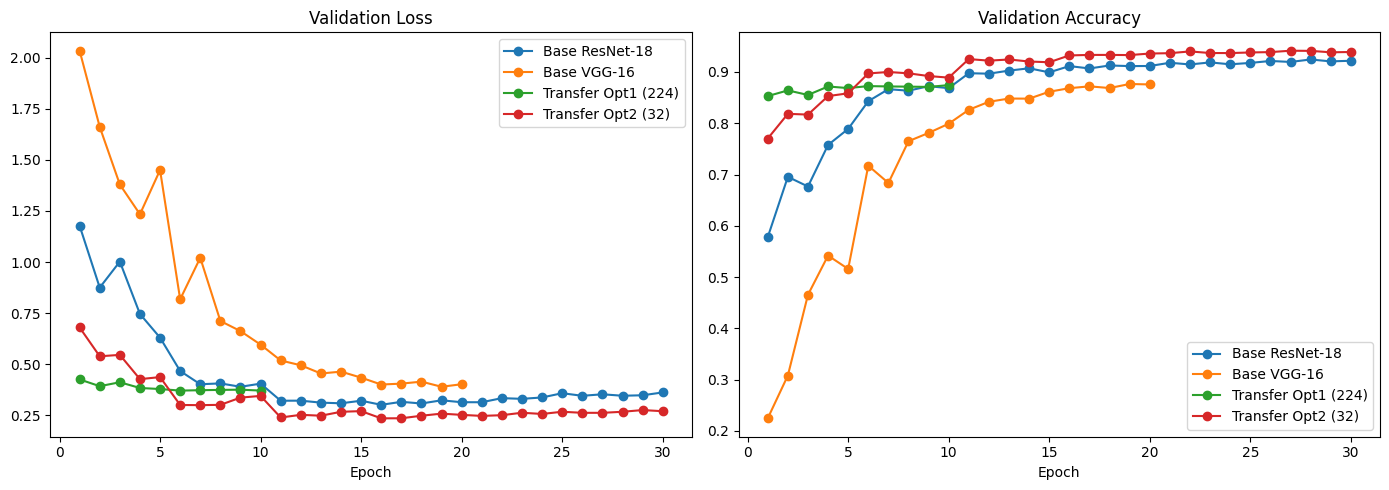

In [11]:
histories = {
    'Base ResNet-18':      hist_resnet,
    'Base VGG-16':         hist_vgg,
    'Transfer Opt1 (224)': hist_opt1,
    'Transfer Opt2 (32)':  hist_opt2,
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, h in histories.items():
    epochs = range(1, len(h['val_loss']) + 1)
    axes[0].plot(epochs, h['val_loss'], marker='o', label=name)
    axes[1].plot(epochs, h['val_acc'],  marker='o', label=name)

axes[0].set_title('Validation Loss');  axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].set_title('Validation Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout()
plt.savefig('part_a_training_curves.png', dpi=150)
plt.show()

## Confusion Matrices

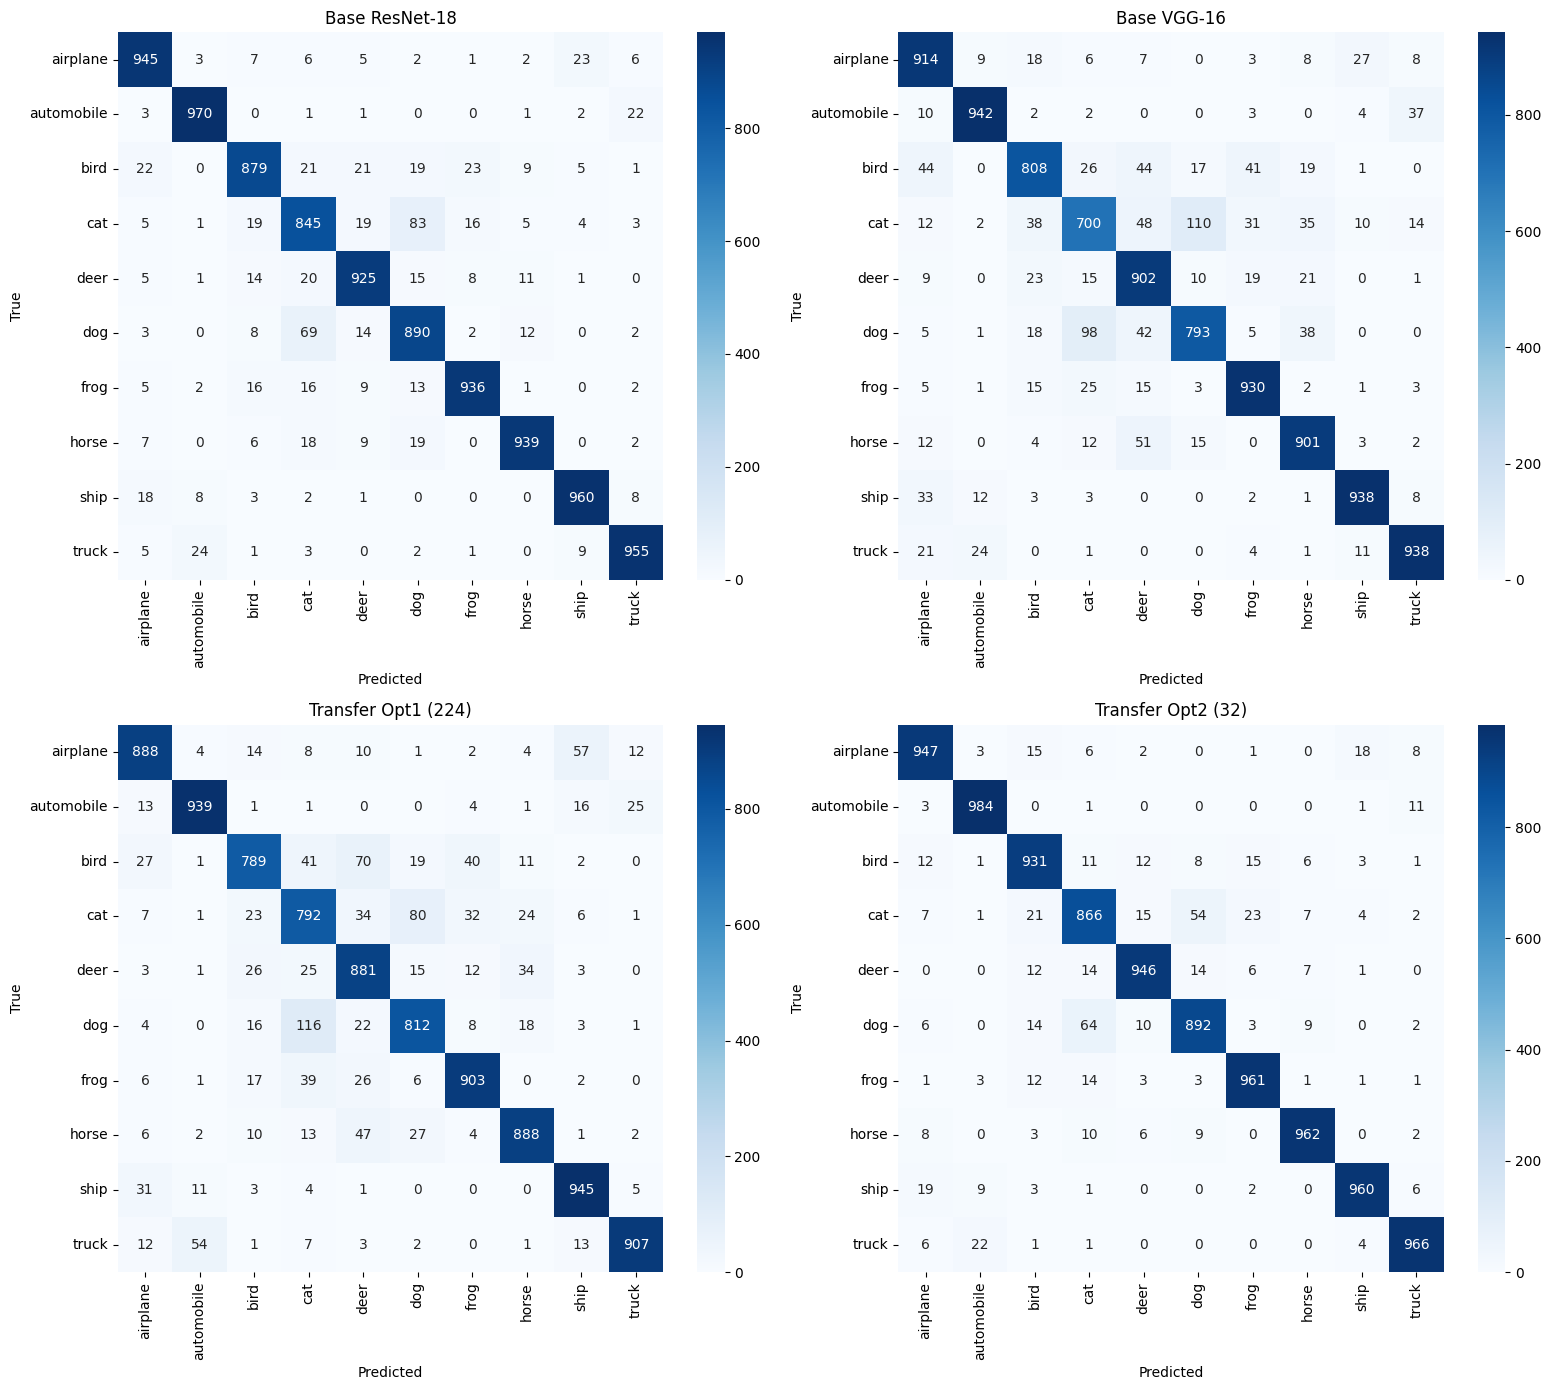

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

for ax, (name, m) in zip(axes.flatten(), results.items()):
    sns.heatmap(m['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.tight_layout()
plt.savefig('part_a_confusion_matrices.png', dpi=150)
plt.show()

## Per-Class IoU Bar Chart

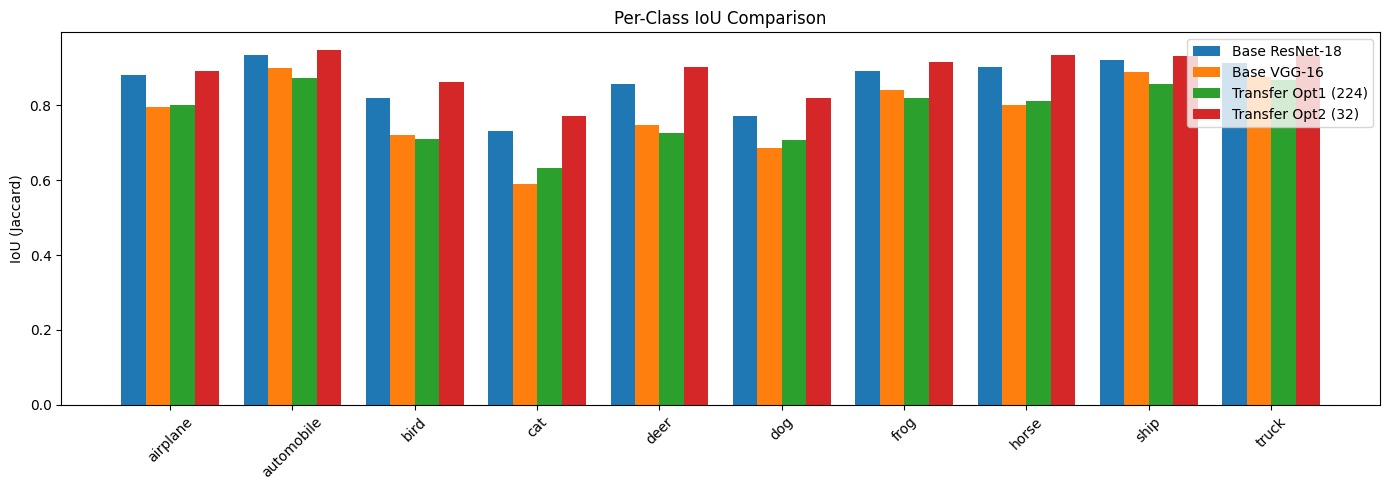

In [13]:
x = np.arange(len(CLASSES))
width = 0.2

fig, ax = plt.subplots(figsize=(14, 5))
for i, (name, m) in enumerate(results.items()):
    ax.bar(x + i * width, m['iou_per_class'], width, label=name)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(CLASSES, rotation=45)
ax.set_ylabel('IoU (Jaccard)')
ax.set_title('Per-Class IoU Comparison')
ax.legend()
plt.tight_layout()
plt.savefig('part_a_iou_per_class.png', dpi=150)
plt.show()

# Part B — Knowledge Distillation

**Step 1:** Train SimpleCNN and ResNet (with & without label smoothing) and compare results.

In [5]:
# ── Part B imports & shared setup ───────────────────────────────────────────
import pandas as pd
from models.CNN import SimpleCNN
from models.ResNet import ResNet, BasicBlock
from train import run_kd_training, DistillationLoss

B_PARAMS = {
    'dataset': 'cifar10', 'data_dir': './data', 'num_workers': 2,
    'mean': (0.4914, 0.4822, 0.4465), 'std': (0.2023, 0.1994, 0.2010),
    'batch_size': 128, 'learning_rate': 1e-3, 'weight_decay': 1e-4,
    'epochs': 30, 'log_interval': 100, 'resize_224': False,
    'label_smoothing': 0.0,
    'kd_temperature': 4.0,
    'kd_alpha': 0.7,
}

b_train_loader, b_val_loader = get_loaders(B_PARAMS)
print(f'Train: {len(b_train_loader)} batches | Val: {len(b_val_loader)} batches')

Train: 391 batches | Val: 79 batches


In [6]:
def train_model_b(model, params, save_path):
    """Train with optional label smoothing; return loss/acc history."""
    criterion = nn.CrossEntropyLoss(label_smoothing=params.get('label_smoothing', 0.0))
    optimizer = torch.optim.Adam(model.parameters(), lr=params['learning_rate'],
                                 weight_decay=params['weight_decay'])
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
    tl, vl = get_loaders(params)
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_acc, best_weights = 0.0, None
    for epoch in range(1, params['epochs'] + 1):
        tr_loss, tr_acc = train_one_epoch(model, tl, optimizer, criterion,
                                          DEVICE, params['log_interval'])
        val_loss, val_acc = validate(model, vl, criterion, DEVICE)
        scheduler.step()
        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        print(f'Epoch {epoch}/{params["epochs"]}  '
              f'train_acc={tr_acc:.4f}  val_acc={val_acc:.4f}')
        if val_acc > best_acc:
            best_acc = val_acc
            best_weights = copy.deepcopy(model.state_dict())
            torch.save(best_weights, save_path)
    model.load_state_dict(best_weights)
    print(f'Best val acc: {best_acc:.4f}')
    return history

## B-Exp 1 — SimpleCNN baseline (standard Cross-Entropy)

In [9]:
# New SimpleCNN: 3 conv blocks (32→64→128) + BN + Dropout, ~1.1M params
simple_cnn = SimpleCNN(num_classes=10).to(DEVICE)
hist_simple = train_model_b(simple_cnn, B_PARAMS, 'best_b_simplecnn.pth')

  [100/391] loss: 2.8172  acc: 0.1480
  [200/391] loss: 2.4616  acc: 0.1773
  [300/391] loss: 2.3108  acc: 0.1922
Epoch 1/30  train_acc=0.2036  val_acc=0.3720
  [100/391] loss: 1.9237  acc: 0.2517
  [200/391] loss: 1.9036  acc: 0.2616
  [300/391] loss: 1.8903  acc: 0.2700
Epoch 2/30  train_acc=0.2764  val_acc=0.4120
  [100/391] loss: 1.8183  acc: 0.2971
  [200/391] loss: 1.8013  acc: 0.3037
  [300/391] loss: 1.7947  acc: 0.3066
Epoch 3/30  train_acc=0.3097  val_acc=0.4708
  [100/391] loss: 1.7561  acc: 0.3178
  [200/391] loss: 1.7477  acc: 0.3228
  [300/391] loss: 1.7399  acc: 0.3257
Epoch 4/30  train_acc=0.3279  val_acc=0.4803
  [100/391] loss: 1.7037  acc: 0.3352
  [200/391] loss: 1.7021  acc: 0.3379
  [300/391] loss: 1.6984  acc: 0.3419
Epoch 5/30  train_acc=0.3455  val_acc=0.5056
  [100/391] loss: 1.6652  acc: 0.3531
  [200/391] loss: 1.6576  acc: 0.3556
  [300/391] loss: 1.6466  acc: 0.3602
Epoch 6/30  train_acc=0.3630  val_acc=0.5513
  [100/391] loss: 1.6002  acc: 0.3734
  [200/3

## B-Exp 2 — ResNet from scratch, no label smoothing

In [10]:
resnet_no_ls = ResNet(BasicBlock, [2, 2, 2, 2], num_classes=10).to(DEVICE)
hist_resnet_no_ls = train_model_b(
    resnet_no_ls, {**B_PARAMS, 'label_smoothing': 0.0}, 'best_b_resnet_no_ls.pth')

  [100/391] loss: 1.8133  acc: 0.3334
  [200/391] loss: 1.6457  acc: 0.3945
  [300/391] loss: 1.5306  acc: 0.4366
Epoch 1/30  train_acc=0.4707  val_acc=0.6073
  [100/391] loss: 1.0535  acc: 0.6210
  [200/391] loss: 1.0173  acc: 0.6325
  [300/391] loss: 0.9847  acc: 0.6469
Epoch 2/30  train_acc=0.6564  val_acc=0.6589
  [100/391] loss: 0.8268  acc: 0.7098
  [200/391] loss: 0.7911  acc: 0.7233
  [300/391] loss: 0.7743  acc: 0.7293
Epoch 3/30  train_acc=0.7341  val_acc=0.6920
  [100/391] loss: 0.6719  acc: 0.7694
  [200/391] loss: 0.6633  acc: 0.7702
  [300/391] loss: 0.6513  acc: 0.7733
Epoch 4/30  train_acc=0.7770  val_acc=0.7710
  [100/391] loss: 0.5835  acc: 0.7977
  [200/391] loss: 0.5783  acc: 0.7988
  [300/391] loss: 0.5709  acc: 0.8018
Epoch 5/30  train_acc=0.8053  val_acc=0.7674
  [100/391] loss: 0.4445  acc: 0.8452
  [200/391] loss: 0.4369  acc: 0.8475
  [300/391] loss: 0.4305  acc: 0.8493
Epoch 6/30  train_acc=0.8506  val_acc=0.8420
  [100/391] loss: 0.3991  acc: 0.8630
  [200/3

## B-Exp 3 — ResNet from scratch, label smoothing ε=0.1

In [11]:
resnet_ls = ResNet(BasicBlock, [2, 2, 2, 2], num_classes=10).to(DEVICE)
hist_resnet_ls = train_model_b(
    resnet_ls, {**B_PARAMS, 'label_smoothing': 0.1}, 'best_b_resnet_ls.pth')

  [100/391] loss: 1.9661  acc: 0.3137
  [200/391] loss: 1.8313  acc: 0.3763
  [300/391] loss: 1.7430  acc: 0.4185
Epoch 1/30  train_acc=0.4488  val_acc=0.5381
  [100/391] loss: 1.3791  acc: 0.5975
  [200/391] loss: 1.3607  acc: 0.6086
  [300/391] loss: 1.3348  acc: 0.6215
Epoch 2/30  train_acc=0.6333  val_acc=0.6284
  [100/391] loss: 1.1977  acc: 0.6887
  [200/391] loss: 1.1826  acc: 0.6987
  [300/391] loss: 1.1616  acc: 0.7084
Epoch 3/30  train_acc=0.7150  val_acc=0.7085
  [100/391] loss: 1.0692  acc: 0.7504
  [200/391] loss: 1.0575  acc: 0.7555
  [300/391] loss: 1.0502  acc: 0.7588
Epoch 4/30  train_acc=0.7636  val_acc=0.7022
  [100/391] loss: 0.9828  acc: 0.7905
  [200/391] loss: 0.9744  acc: 0.7929
  [300/391] loss: 0.9712  acc: 0.7957
Epoch 5/30  train_acc=0.7989  val_acc=0.7540
  [100/391] loss: 0.8792  acc: 0.8382
  [200/391] loss: 0.8708  acc: 0.8414
  [300/391] loss: 0.8658  acc: 0.8435
Epoch 6/30  train_acc=0.8443  val_acc=0.8179
  [100/391] loss: 0.8294  acc: 0.8580
  [200/3

## Comparison — accuracy, ECE, confidence histograms

ECE (Expected Calibration Error): measures how well model confidence matches actual accuracy.
Label smoothing is expected to lower ECE (better calibrated) without large accuracy change.

In [12]:
def expected_calibration_error(model, loader, n_bins=15):
    model.eval()
    all_conf, all_correct = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            probs = torch.softmax(model(imgs), dim=-1)
            conf, preds = probs.max(1)
            all_conf.extend(conf.cpu().numpy())
            all_correct.extend(preds.eq(labels).cpu().numpy())
    all_conf    = np.array(all_conf)
    all_correct = np.array(all_correct)
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        mask = (all_conf >= bins[i]) & (all_conf < bins[i+1])
        if mask.sum() == 0:
            continue
        ece += mask.sum() * abs(all_correct[mask].mean() - all_conf[mask].mean())
    return ece / len(all_conf)

def max_confidences(model, loader):
    model.eval()
    confs = []
    with torch.no_grad():
        for imgs, _ in loader:
            probs = torch.softmax(model(imgs.to(DEVICE)), dim=-1)
            confs.extend(probs.max(1).values.cpu().numpy())
    return np.array(confs)

ece_no_ls  = expected_calibration_error(resnet_no_ls, b_val_loader)
ece_ls     = expected_calibration_error(resnet_ls,    b_val_loader)
conf_no_ls = max_confidences(resnet_no_ls, b_val_loader)
conf_ls    = max_confidences(resnet_ls,    b_val_loader)

print(f'ResNet no LS   best_acc={max(hist_resnet_no_ls["val_acc"]):.4f}  ECE={ece_no_ls:.4f}')
print(f'ResNet LS=0.1  best_acc={max(hist_resnet_ls["val_acc"]):.4f}  ECE={ece_ls:.4f}')

ResNet no LS   best_acc=0.9189  ECE=0.0507
ResNet LS=0.1  best_acc=0.9197  ECE=0.0599


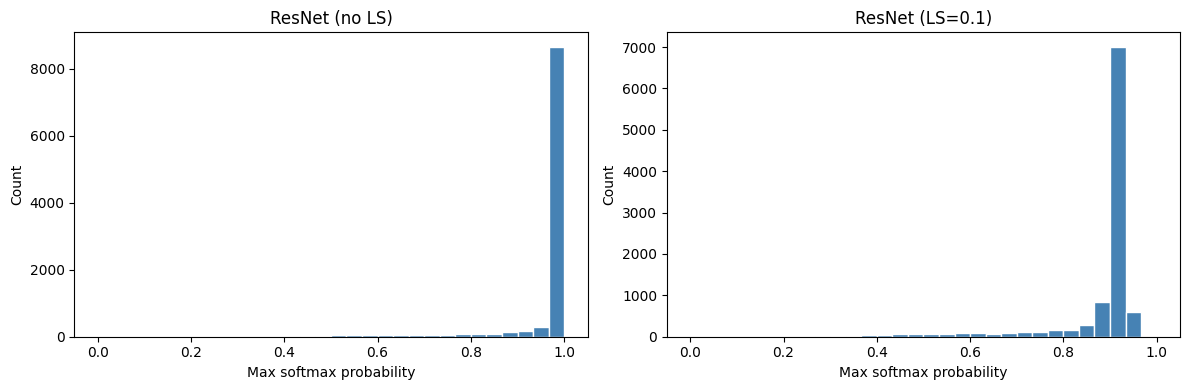

In [13]:
# Confidence histograms
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, confs, label in zip(axes, [conf_no_ls, conf_ls],
                             ['ResNet (no LS)', 'ResNet (LS=0.1)']):
    ax.hist(confs, bins=30, range=(0, 1), color='steelblue', edgecolor='white')
    ax.set_title(label)
    ax.set_xlabel('Max softmax probability')
    ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('part_b_confidence_histograms.png', dpi=150)
plt.show()

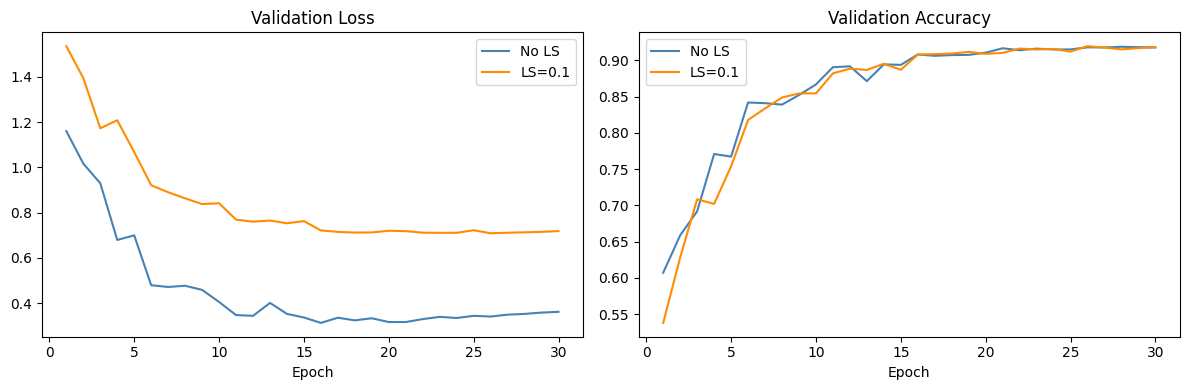

In [14]:
# Training curves: no LS vs LS
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, h, c in [('No LS',   hist_resnet_no_ls, 'steelblue'),
                    ('LS=0.1',  hist_resnet_ls,    'darkorange')]:
    ep = range(1, len(h['val_acc']) + 1)
    axes[0].plot(ep, h['val_loss'], label=name, color=c)
    axes[1].plot(ep, h['val_acc'],  label=name, color=c)
axes[0].set_title('Validation Loss');    axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].set_title('Validation Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout()
plt.savefig('part_b_resnet_ls_curves.png', dpi=150)
plt.show()

In [15]:
# Summary table: SimpleCNN vs ResNet no-LS vs ResNet LS
ce_eval = nn.CrossEntropyLoss()
rows = []
for name, mdl, hist in [
    ('SimpleCNN (baseline)',  simple_cnn,    hist_simple),
    ('ResNet (no LS)',        resnet_no_ls,  hist_resnet_no_ls),
    ('ResNet (LS=0.1)',       resnet_ls,     hist_resnet_ls),
]:
    _, acc = validate(mdl, b_val_loader, ce_eval, DEVICE)
    ece_v  = expected_calibration_error(mdl, b_val_loader)
    rows.append({'Model': name,
                 'Best Val Acc': f'{max(hist["val_acc"])*100:.2f}%',
                 'Final Val Acc': f'{acc*100:.2f}%',
                 'ECE': f'{ece_v:.4f}'})
pd.DataFrame(rows)

,Model,Best Val Acc,Final Val Acc,ECE
0,SimpleCNN (baseline),69.88%,69.88%,0.1421
1,ResNet (no LS),91.89%,91.89%,0.0507
2,ResNet (LS=0.1),91.97%,91.97%,0.0599


## B-Exp 4 — KD: ResNet (no LS) teacher → SimpleCNN student

In [16]:
# Load best no-LS ResNet teacher
teacher_no_ls = ResNet(BasicBlock, [2, 2, 2, 2], num_classes=10).to(DEVICE)
teacher_no_ls.load_state_dict(torch.load('best_b_resnet_no_ls.pth', map_location=DEVICE))

student_kd_b = SimpleCNN(num_classes=10).to(DEVICE)
hist_kd_b = run_kd_training(
    student_kd_b, teacher_no_ls,
    {**B_PARAMS, 'save_path': 'best_b_simplecnn_kd_b.pth'},
    DEVICE,
)

  [100/391] loss: 15.0597  acc: 0.2440
  [200/391] loss: 13.8395  acc: 0.2835
  [300/391] loss: 13.1022  acc: 0.3118

Epoch 1/30  train_acc=0.3316  val_acc=0.5069
  Saved best model (val_acc=0.5069)
  [100/391] loss: 10.8008  acc: 0.4166
  [200/391] loss: 10.6034  acc: 0.4271
  [300/391] loss: 10.4728  acc: 0.4330

Epoch 2/30  train_acc=0.4396  val_acc=0.6062
  Saved best model (val_acc=0.6062)
  [100/391] loss: 9.6372  acc: 0.4823
  [200/391] loss: 9.5497  acc: 0.4848
  [300/391] loss: 9.4826  acc: 0.4880

Epoch 3/30  train_acc=0.4918  val_acc=0.6308
  Saved best model (val_acc=0.6308)
  [100/391] loss: 9.1208  acc: 0.5013
  [200/391] loss: 9.0860  acc: 0.5060
  [300/391] loss: 9.0503  acc: 0.5090

Epoch 4/30  train_acc=0.5112  val_acc=0.6519
  Saved best model (val_acc=0.6519)
  [100/391] loss: 8.8189  acc: 0.5227
  [200/391] loss: 8.6947  acc: 0.5298
  [300/391] loss: 8.6919  acc: 0.5305

Epoch 5/30  train_acc=0.5310  val_acc=0.6810
  Saved best model (val_acc=0.6810)
  [100/391] lo

## B-Exp 5 — KD: ResNet (LS=0.1) teacher → SimpleCNN student

In [17]:
# Load best LS=0.1 ResNet teacher
teacher_ls = ResNet(BasicBlock, [2, 2, 2, 2], num_classes=10).to(DEVICE)
teacher_ls.load_state_dict(torch.load('best_b_resnet_ls.pth', map_location=DEVICE))

student_kd_c = SimpleCNN(num_classes=10).to(DEVICE)
hist_kd_c = run_kd_training(
    student_kd_c, teacher_ls,
    {**B_PARAMS, 'save_path': 'best_b_simplecnn_kd_c.pth'},
    DEVICE,
)

  [100/391] loss: 2.5107  acc: 0.1147
  [200/391] loss: 2.1461  acc: 0.1240
  [300/391] loss: 2.0215  acc: 0.1297

Epoch 1/30  train_acc=0.1325  val_acc=0.1779
  Saved best model (val_acc=0.1779)
  [100/391] loss: 1.7640  acc: 0.1429
  [200/391] loss: 1.7625  acc: 0.1418
  [300/391] loss: 1.7613  acc: 0.1429

Epoch 2/30  train_acc=0.1449  val_acc=0.2002
  Saved best model (val_acc=0.2002)
  [100/391] loss: 1.7570  acc: 0.1459
  [200/391] loss: 1.7554  acc: 0.1470
  [300/391] loss: 1.7549  acc: 0.1481

Epoch 3/30  train_acc=0.1468  val_acc=0.2115
  Saved best model (val_acc=0.2115)
  [100/391] loss: 1.7586  acc: 0.1468
  [200/391] loss: 1.7575  acc: 0.1461
  [300/391] loss: 1.7554  acc: 0.1478

Epoch 4/30  train_acc=0.1479  val_acc=0.2016
  [100/391] loss: 1.7502  acc: 0.1484
  [200/391] loss: 1.7503  acc: 0.1491
  [300/391] loss: 1.7495  acc: 0.1507

Epoch 5/30  train_acc=0.1572  val_acc=0.2147
  Saved best model (val_acc=0.2147)
  [100/391] loss: 1.7179  acc: 0.1730
  [200/391] loss: 

## B — Step 2 Results: FLOPs / Params Table & Training Curves

In [18]:
# ── FLOPs & Params table (ptflops) ──────────────────────────────────────────
from ptflops import get_model_complexity_info

ce_eval = nn.CrossEntropyLoss()

flops_rows = []
for name, mdl, hist in [
    ('ResNet (no LS)',           resnet_no_ls,   hist_resnet_no_ls),
    ('ResNet (LS=0.1)',          resnet_ls,       hist_resnet_ls),
    ('SimpleCNN scratch',        simple_cnn,      hist_simple),
    ('SimpleCNN KD-B (no-LS teacher)', student_kd_b, hist_kd_b),
    ('SimpleCNN KD-C (LS teacher)',    student_kd_c, hist_kd_c),
]:
    macs, n_params = get_model_complexity_info(
        mdl, (3, 32, 32),
        as_strings=False,
        print_per_layer_stat=False,
        verbose=False,
    )
    _, val_acc = validate(mdl, b_val_loader, ce_eval, DEVICE)
    flops_rows.append({
        'Model':          name,
        'Best Val Acc':   f'{max(hist["val_acc"])*100:.2f}%',
        'MACs (M)':       f'{macs / 1e6:.2f}',
        'Params (M)':     f'{n_params / 1e6:.3f}',
    })

pd.DataFrame(flops_rows)

,Model,Best Val Acc,MACs (M),Params (M)
0,ResNet (no LS),91.89%,557.22,11.174
1,ResNet (LS=0.1),91.97%,557.22,11.174
2,SimpleCNN scratch,69.88%,41.59,2.194
3,SimpleCNN KD-B (no-LS teacher),77.90%,41.59,2.194
4,SimpleCNN KD-C (LS teacher),65.70%,41.59,2.194


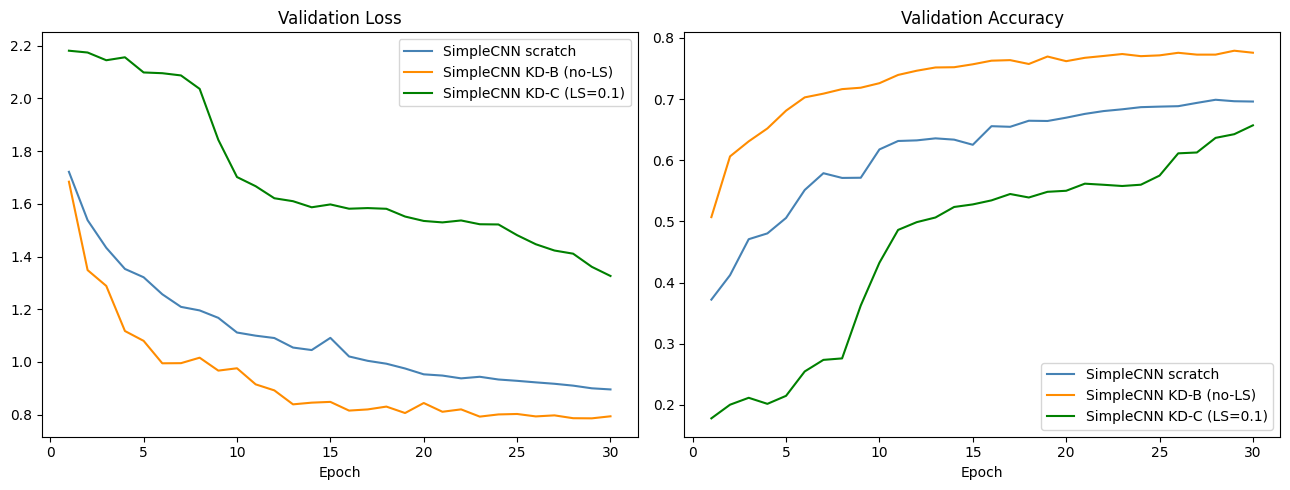

In [19]:
# ── Training curves: SimpleCNN scratch vs KD-B vs KD-C ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, h, c in [
    ('SimpleCNN scratch',        hist_simple, 'steelblue'),
    ('SimpleCNN KD-B (no-LS)',   hist_kd_b,   'darkorange'),
    ('SimpleCNN KD-C (LS=0.1)', hist_kd_c,   'green'),
]:
    ep = range(1, len(h['val_acc']) + 1)
    axes[0].plot(ep, h['val_loss'], label=name, color=c)
    axes[1].plot(ep, h['val_acc'],  label=name, color=c)

axes[0].set_title('Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[1].set_title('Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()
plt.tight_layout()
plt.savefig('part_b_kd_curves.png', dpi=150)
plt.show()

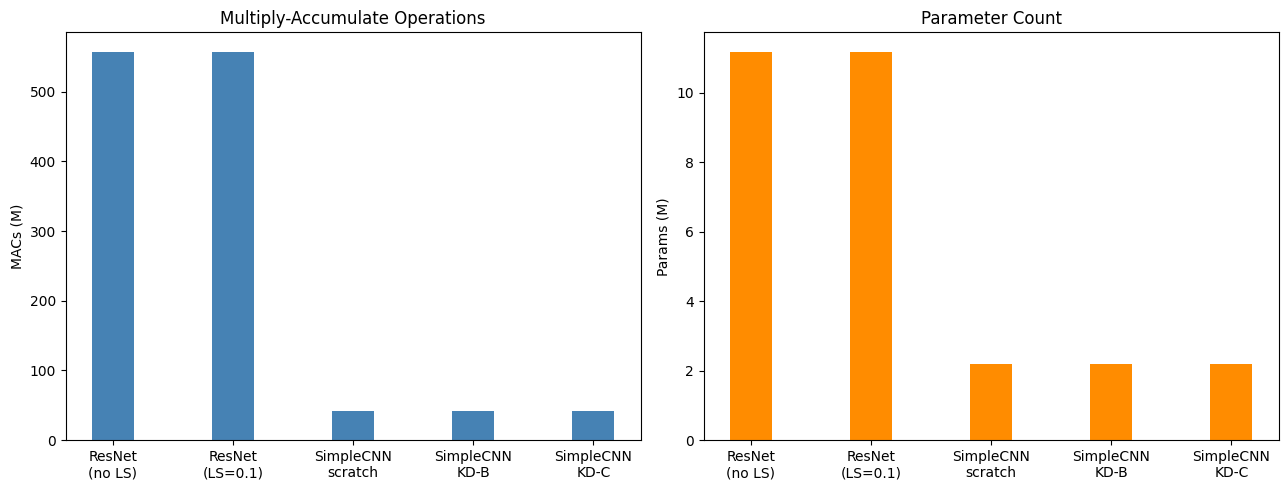

In [20]:
# ── Bar chart: MACs and Params side by side ──────────────────────────────────
from ptflops import get_model_complexity_info

model_names = [
    'ResNet\n(no LS)',
    'ResNet\n(LS=0.1)',
    'SimpleCNN\nscratch',
    'SimpleCNN\nKD-B',
    'SimpleCNN\nKD-C',
]
models_list = [resnet_no_ls, resnet_ls, simple_cnn, student_kd_b, student_kd_c]

macs_list, params_list = [], []
for mdl in models_list:
    m, p = get_model_complexity_info(
        mdl, (3, 32, 32), as_strings=False,
        print_per_layer_stat=False, verbose=False,
    )
    macs_list.append(m / 1e6)
    params_list.append(p / 1e6)

x = np.arange(len(model_names))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(x, macs_list, width, color='steelblue')
axes[0].set_xticks(x); axes[0].set_xticklabels(model_names)
axes[0].set_ylabel('MACs (M)'); axes[0].set_title('Multiply-Accumulate Operations')

axes[1].bar(x, params_list, width, color='darkorange')
axes[1].set_xticks(x); axes[1].set_xticklabels(model_names)
axes[1].set_ylabel('Params (M)'); axes[1].set_title('Parameter Count')

plt.tight_layout()
plt.savefig('part_b_flops_bar.png', dpi=150)
plt.show()

# Part B — Step 3: Teacher-Guided Label Smoothing KD with MobileNetV2

In [21]:
from models.mobilenet import MobileNetV2
from train import TeacherGuidedLSLoss

## B-Exp 6 — MobileNetV2 baseline (scratch, standard CE)

In [22]:
mobilenet_base = MobileNetV2(num_classes=10).to(DEVICE)
hist_mobilenet = train_model_b(mobilenet_base, B_PARAMS, 'best_b_mobilenet.pth')

  [100/391] loss: 1.8165  acc: 0.3195
  [200/391] loss: 1.6742  acc: 0.3782
  [300/391] loss: 1.5887  acc: 0.4149
Epoch 1/30  train_acc=0.4425  val_acc=0.5404
  [100/391] loss: 1.2057  acc: 0.5630
  [200/391] loss: 1.1621  acc: 0.5797
  [300/391] loss: 1.1257  acc: 0.5944
Epoch 2/30  train_acc=0.6066  val_acc=0.6243
  [100/391] loss: 0.9695  acc: 0.6520
  [200/391] loss: 0.9410  acc: 0.6652
  [300/391] loss: 0.9135  acc: 0.6753
Epoch 3/30  train_acc=0.6836  val_acc=0.7124
  [100/391] loss: 0.7683  acc: 0.7280
  [200/391] loss: 0.7626  acc: 0.7343
  [300/391] loss: 0.7505  acc: 0.7376
Epoch 4/30  train_acc=0.7417  val_acc=0.7578
  [100/391] loss: 0.6680  acc: 0.7666
  [200/391] loss: 0.6647  acc: 0.7705
  [300/391] loss: 0.6575  acc: 0.7717
Epoch 5/30  train_acc=0.7726  val_acc=0.7714
  [100/391] loss: 0.5333  acc: 0.8159
  [200/391] loss: 0.5261  acc: 0.8180
  [300/391] loss: 0.5235  acc: 0.8184
Epoch 6/30  train_acc=0.8186  val_acc=0.8096
  [100/391] loss: 0.4799  acc: 0.8319
  [200/3

## B-Exp 7 — MobileNet + TGLS-KD (no-LS ResNet teacher, T=1.0)

In [23]:
teacher_no_ls = ResNet(BasicBlock, [2,2,2,2], num_classes=10).to(DEVICE)
teacher_no_ls.load_state_dict(torch.load('best_b_resnet_no_ls.pth', map_location=DEVICE))

student_tgls_b = MobileNetV2(num_classes=10).to(DEVICE)
hist_tgls_b = run_kd_training(
    student_tgls_b, teacher_no_ls,
    {**B_PARAMS, 'save_path': 'best_b_mobilenet_tgls_b.pth'},
    DEVICE,
    criterion=TeacherGuidedLSLoss(temperature=1.0),
)

  [100/391] loss: 1.8611  acc: 0.3025
  [200/391] loss: 1.7191  acc: 0.3628
  [300/391] loss: 1.6257  acc: 0.4010

Epoch 1/30  train_acc=0.4297  val_acc=0.4970
  Saved best model (val_acc=0.4970)
  [100/391] loss: 1.2555  acc: 0.5594
  [200/391] loss: 1.2130  acc: 0.5752
  [300/391] loss: 1.1712  acc: 0.5908

Epoch 2/30  train_acc=0.6036  val_acc=0.6674
  Saved best model (val_acc=0.6674)
  [100/391] loss: 0.9698  acc: 0.6667
  [200/391] loss: 0.9609  acc: 0.6757
  [300/391] loss: 0.9354  acc: 0.6848

Epoch 3/30  train_acc=0.6925  val_acc=0.7265
  Saved best model (val_acc=0.7265)
  [100/391] loss: 0.8100  acc: 0.7324
  [200/391] loss: 0.7970  acc: 0.7377
  [300/391] loss: 0.7881  acc: 0.7392

Epoch 4/30  train_acc=0.7446  val_acc=0.7510
  Saved best model (val_acc=0.7510)
  [100/391] loss: 0.7128  acc: 0.7684
  [200/391] loss: 0.7074  acc: 0.7693
  [300/391] loss: 0.6974  acc: 0.7731

Epoch 5/30  train_acc=0.7761  val_acc=0.7663
  Saved best model (val_acc=0.7663)
  [100/391] loss: 0.

## B-Exp 8 — MobileNet + TGLS-KD (LS=0.1 ResNet teacher, T=1.0)

In [24]:
teacher_ls = ResNet(BasicBlock, [2,2,2,2], num_classes=10).to(DEVICE)
teacher_ls.load_state_dict(torch.load('best_b_resnet_ls.pth', map_location=DEVICE))

student_tgls_c = MobileNetV2(num_classes=10).to(DEVICE)
hist_tgls_c = run_kd_training(
    student_tgls_c, teacher_ls,
    {**B_PARAMS, 'save_path': 'best_b_mobilenet_tgls_c.pth'},
    DEVICE,
    criterion=TeacherGuidedLSLoss(temperature=1.0),
)

  [100/391] loss: 1.9543  acc: 0.3202
  [200/391] loss: 1.8403  acc: 0.3748
  [300/391] loss: 1.7653  acc: 0.4136

Epoch 1/30  train_acc=0.4415  val_acc=0.5426
  Saved best model (val_acc=0.5426)
  [100/391] loss: 1.4536  acc: 0.5774
  [200/391] loss: 1.4295  acc: 0.5881
  [300/391] loss: 1.4004  acc: 0.6021

Epoch 2/30  train_acc=0.6141  val_acc=0.6342
  Saved best model (val_acc=0.6342)
  [100/391] loss: 1.2332  acc: 0.6838
  [200/391] loss: 1.2219  acc: 0.6901
  [300/391] loss: 1.2093  acc: 0.6946

Epoch 3/30  train_acc=0.6995  val_acc=0.7324
  Saved best model (val_acc=0.7324)
  [100/391] loss: 1.1101  acc: 0.7403
  [200/391] loss: 1.0970  acc: 0.7477
  [300/391] loss: 1.0870  acc: 0.7513

Epoch 4/30  train_acc=0.7532  val_acc=0.7529
  Saved best model (val_acc=0.7529)
  [100/391] loss: 1.0323  acc: 0.7745
  [200/391] loss: 1.0344  acc: 0.7743
  [300/391] loss: 1.0278  acc: 0.7783

Epoch 5/30  train_acc=0.7820  val_acc=0.7875
  Saved best model (val_acc=0.7875)
  [100/391] loss: 0.

## B — Step 3 Results: FLOPs / Params Table & Training Curves

In [25]:
from ptflops import get_model_complexity_info

ce_eval = nn.CrossEntropyLoss()
rows = []
for name, mdl, hist in [
    ('ResNet (no LS)',              resnet_no_ls,    hist_resnet_no_ls),
    ('ResNet (LS=0.1)',             resnet_ls,       hist_resnet_ls),
    ('MobileNetV2 scratch',         mobilenet_base,  hist_mobilenet),
    ('MobileNetV2 TGLS-B (no-LS)', student_tgls_b,  hist_tgls_b),
    ('MobileNetV2 TGLS-C (LS)',     student_tgls_c,  hist_tgls_c),
]:
    macs, n_params = get_model_complexity_info(
        mdl, (3, 32, 32), as_strings=False,
        print_per_layer_stat=False, verbose=False)
    _, val_acc = validate(mdl, b_val_loader, ce_eval, DEVICE)
    rows.append({
        'Model':        name,
        'Best Val Acc': f'{max(hist["val_acc"])*100:.2f}%',
        'MACs (M)':     f'{macs/1e6:.2f}',
        'Params (M)':   f'{n_params/1e6:.3f}',
    })
pd.DataFrame(rows)

,Model,Best Val Acc,MACs (M),Params (M)
0,ResNet (no LS),91.89%,557.22,11.174
1,ResNet (LS=0.1),91.97%,557.22,11.174
2,MobileNetV2 scratch,89.23%,96.16,2.297
3,MobileNetV2 TGLS-B (no-LS),89.56%,96.16,2.297
4,MobileNetV2 TGLS-C (LS),89.72%,96.16,2.297


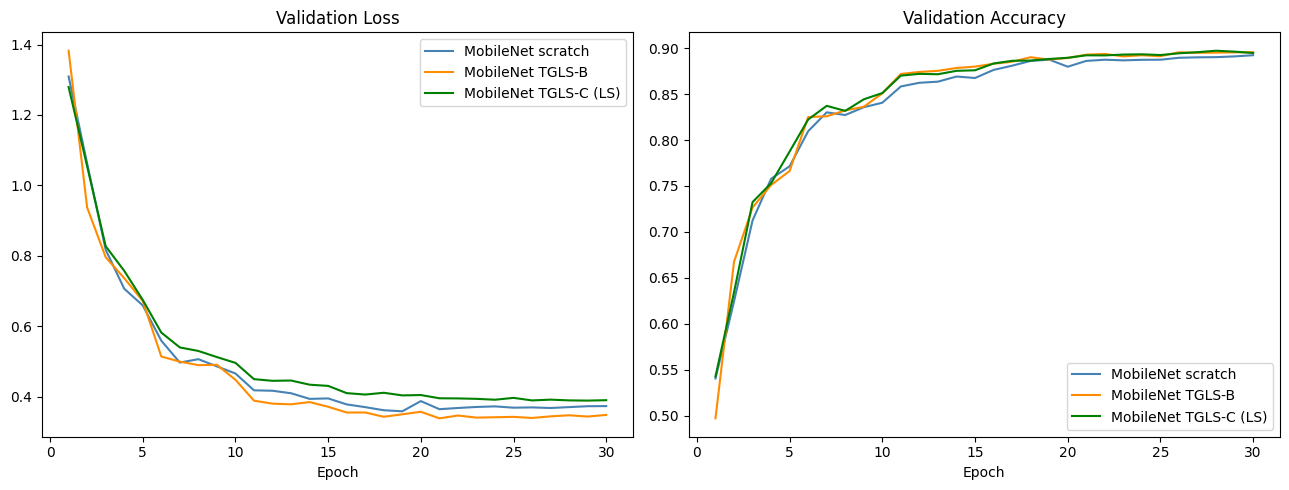

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for name, h, c in [
    ('MobileNet scratch',      hist_mobilenet, 'steelblue'),
    ('MobileNet TGLS-B',       hist_tgls_b,    'darkorange'),
    ('MobileNet TGLS-C (LS)',  hist_tgls_c,    'green'),
]:
    ep = range(1, len(h['val_acc']) + 1)
    axes[0].plot(ep, h['val_loss'], label=name, color=c)
    axes[1].plot(ep, h['val_acc'],  label=name, color=c)
axes[0].set_title('Validation Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].set_title('Validation Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout()
plt.savefig('part_b_tgls_curves.png', dpi=150)
plt.show()

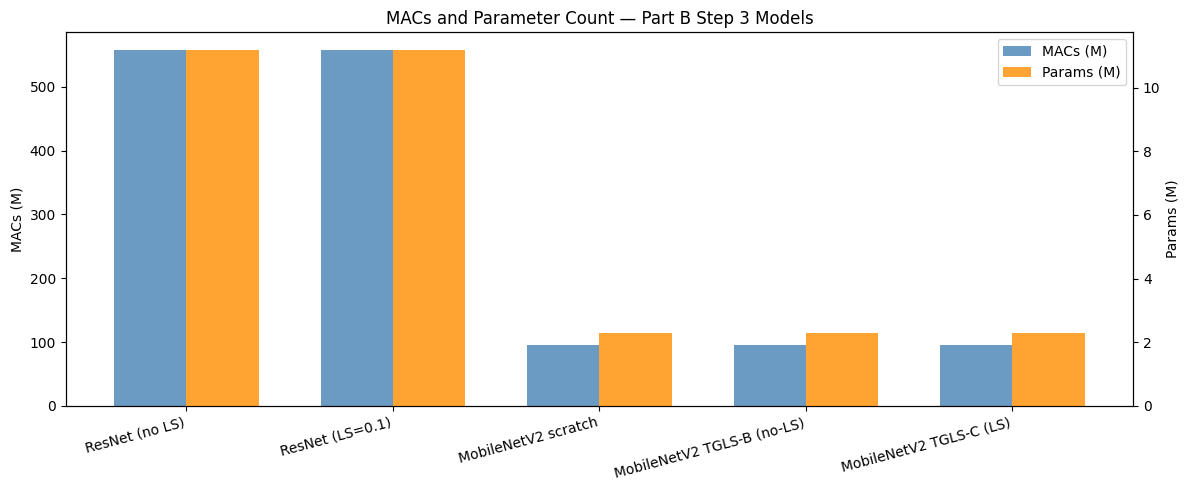

In [27]:
# ── Bar chart: MACs and Params for all 5 models ────────────────────────────────
from ptflops import get_model_complexity_info

model_entries = [
    ('ResNet (no LS)',              resnet_no_ls),
    ('ResNet (LS=0.1)',             resnet_ls),
    ('MobileNetV2 scratch',         mobilenet_base),
    ('MobileNetV2 TGLS-B (no-LS)', student_tgls_b),
    ('MobileNetV2 TGLS-C (LS)',     student_tgls_c),
]

names_bar, macs_bar, params_bar = [], [], []
for name, mdl in model_entries:
    macs, n_params = get_model_complexity_info(
        mdl, (3, 32, 32), as_strings=False,
        print_per_layer_stat=False, verbose=False)
    names_bar.append(name)
    macs_bar.append(macs / 1e6)
    params_bar.append(n_params / 1e6)

x = np.arange(len(names_bar))
width = 0.35
fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()
ax1.bar(x - width/2, macs_bar,   width, label='MACs (M)',    color='steelblue', alpha=0.8)
ax2.bar(x + width/2, params_bar, width, label='Params (M)',  color='darkorange', alpha=0.8)
ax1.set_xticks(x); ax1.set_xticklabels(names_bar, rotation=15, ha='right')
ax1.set_ylabel('MACs (M)'); ax2.set_ylabel('Params (M)')
ax1.set_title('MACs and Parameter Count — Part B Step 3 Models')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
plt.tight_layout()
plt.savefig('part_b_tgls_bar.png', dpi=150)
plt.show()

## Visualization — TSNE

Extract penultimate-layer (avgpool) features from the trained ResNet (no LS) on the CIFAR-10 validation set,
reduce to 2-D with TSNE, and plot coloured by class label.

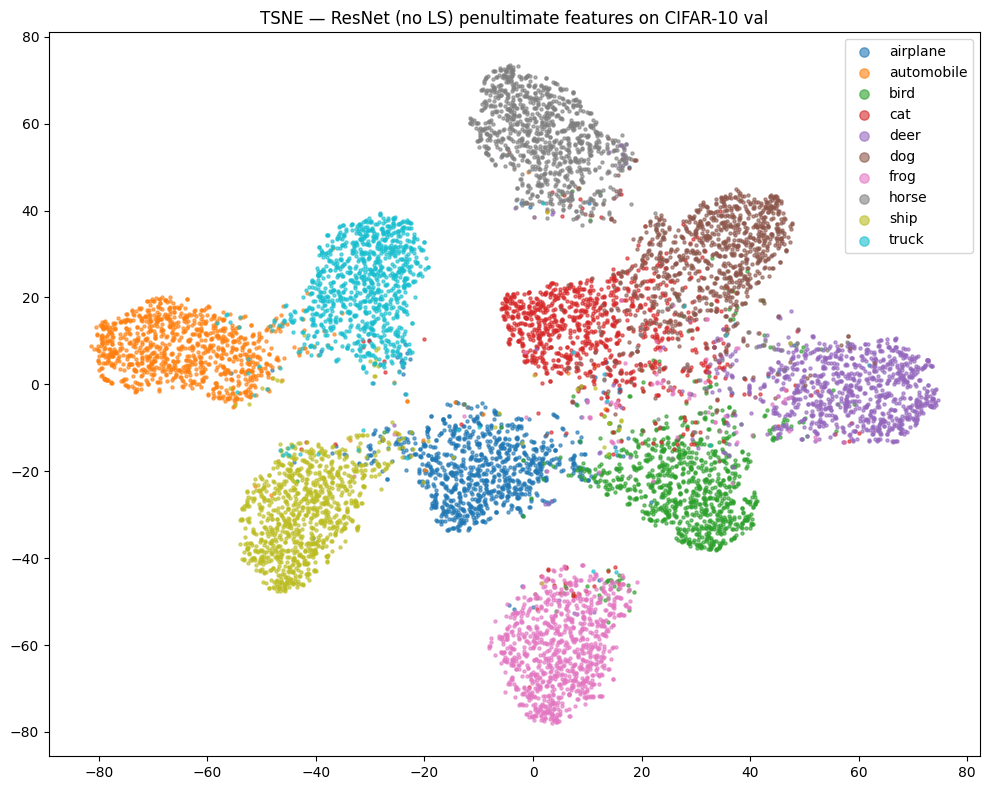

In [28]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# ── collect penultimate features via a forward hook ──────────────────────────
features_list, labels_list = [], []

def hook_fn(module, input, output):
    features_list.append(output.detach().cpu())

handle = resnet_no_ls.avgpool.register_forward_hook(hook_fn)

resnet_no_ls.eval()
with torch.no_grad():
    for imgs, lbls in b_val_loader:
        imgs = imgs.to(DEVICE)
        resnet_no_ls(imgs)
        labels_list.append(lbls)

handle.remove()

feats = torch.cat(features_list).squeeze().numpy()  # (N, 512)
labs  = torch.cat(labels_list).numpy()

# ── fit TSNE ─────────────────────────────────────────────────────────────────
tsne = TSNE(n_components=2, perplexity=40, random_state=42)
emb  = tsne.fit_transform(feats)

# ── plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
for c in range(10):
    mask = labs == c
    ax.scatter(emb[mask, 0], emb[mask, 1], s=5, label=CLASSES[c], alpha=0.6)
ax.legend(markerscale=3)
ax.set_title('TSNE — ResNet (no LS) penultimate features on CIFAR-10 val')
plt.tight_layout()
plt.savefig('tsne_resnet_no_ls.png', dpi=150)
plt.show()